# 04 — Avaliação e Interpretação

Aqui a análise deixa de ser técnica e passa a ser de negócio. O conjunto de teste (20% dos
clientes, perfis nunca vistos no treino) é usado **pela primeira vez** neste notebook. Nenhuma
escolha de modelo ou de ponto de corte é feita olhando para ele.

In [1]:
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
    average_precision_score, confusion_matrix, roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict

from src.config import CV_FOLDS, DATA_PROCESSED, GROUP, METRICS, MODELS, PROCESSED_FILE, TARGET
from src.data import load_processed
from src.evaluation import comparison_table, score
from src.viz import COR_BOM, COR_MAU, COR_NEUTRA, CORES_MODELOS, aplicar_estilo, salvar

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
aplicar_estilo()

In [2]:
df = load_processed(PROCESSED_FILE)
split = pd.read_csv(DATA_PROCESSED / "split.csv")
assert (split["ID"].values == df["ID"].values).all()

pacote = joblib.load(MODELS / "modelos.joblib")
modelos, escolhido = pacote["modelos"], pacote["escolhido"]
FEATURES = pacote["num"] + pacote["cat"]

treino = df[split["conjunto"].values == "treino"]
teste = df[split["conjunto"].values == "teste"]
X_test, y_test = teste[FEATURES], teste[TARGET]
nomes = {"regressao_logistica": "Regressão Logística", "random_forest": "Random Forest",
         "gradient_boosting": "Gradient Boosting"}
print("Modelo escolhido no notebook 03:", nomes[escolhido])
print("Teste:", len(teste), "clientes,", y_test.sum(), "maus pagadores")

Modelo escolhido no notebook 03: Regressão Logística
Teste: 7354 clientes, 126 maus pagadores


## 1. Métricas no conjunto de teste

Todas as métricas abaixo usam o ponto de corte padrão de probabilidade 0,5, exceto PR-AUC e
AUC-ROC, que avaliam a ordenação inteira. Como o teste tem só 126 maus pagadores, cada métrica
de ordenação vem acompanhada de um **intervalo de confiança de 95% por bootstrap**: o teste é
reamostrado 1.000 vezes com reposição.

In [3]:
probas = {nome: m.predict_proba(X_test)[:, 1] for nome, m in modelos.items()}
resultados = {nome: score(y_test, (p >= 0.5).astype(int), p) for nome, p in probas.items()}
tabela = comparison_table(resultados)
tabela

,accuracy,precision,recall,f1,roc_auc,pr_auc
random_forest,0.9806,0.1852,0.0397,0.0654,0.5978,0.0604
regressao_logistica,0.6282,0.0170,0.3651,0.0326,0.5113,0.0535
gradient_boosting,0.8005,0.0275,0.3095,0.0505,0.5591,0.0273


In [4]:
def bootstrap_ic(y, p, n=1000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y, p = np.asarray(y), np.asarray(p)
    aucs, aps = [], []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if y[i].sum() == 0:
            continue
        aucs.append(roc_auc_score(y[i], p[i]))
        aps.append(average_precision_score(y[i], p[i]))
    return np.percentile(aucs, [2.5, 97.5]), np.percentile(aps, [2.5, 97.5])

linhas = []
for nome, p in probas.items():
    ic_auc, ic_ap = bootstrap_ic(y_test, p)
    linhas.append({"modelo": nomes[nome],
                   "AUC-ROC": roc_auc_score(y_test, p), "AUC-ROC IC95%": f"{ic_auc[0]:.3f} – {ic_auc[1]:.3f}",
                   "PR-AUC": average_precision_score(y_test, p), "PR-AUC IC95%": f"{ic_ap[0]:.3f} – {ic_ap[1]:.3f}"})
incerteza = pd.DataFrame(linhas).set_index("modelo").round(3)
incerteza.to_csv(METRICS / "teste_intervalos.csv")
print("Proporção de maus no teste (PR-AUC de um modelo sem informação):", round(y_test.mean(), 4))
incerteza

Proporção de maus no teste (PR-AUC de um modelo sem informação): 0.0171


,AUC-ROC,AUC-ROC IC95%,PR-AUC,PR-AUC IC95%
modelo,,,,
Regressão Logística,0.511,0.456 – 0.565,0.053,0.027 – 0.093
Random Forest,0.598,0.545 – 0.657,0.060,0.029 – 0.101
Gradient Boosting,0.559,0.504 – 0.614,0.027,0.019 – 0.042


**Leitura (o resultado mais importante do projeto):**

- **A Regressão Logística, escolhida no notebook 03, teve AUC-ROC de 0,511 no teste.** O
  intervalo de 95% (0,456–0,565) **inclui 0,5**. Na ordenação completa dos clientes, ela não se
  distinguiu do acaso. Na validação cruzada a AUC tinha sido 0,578 ± 0,021. O teste ficou bem
  abaixo.
- **O Random Forest foi o melhor no teste:** AUC de 0,598, com intervalo de 0,545–0,657, acima de 0,5.
  **Não trocamos de modelo por causa disso.** Escolher o vencedor olhando o teste transformaria o
  teste em mais uma rodada de seleção, e o número reportado deixaria de ser uma estimativa
  honesta. O que este resultado mostra é que **a diferença entre os modelos é menor que a
  incerteza da medição**. Os intervalos dos três se sobrepõem, exatamente como na validação
  cruzada.
- **PR-AUC:** Logística 0,053 e Random Forest 0,060 ficam cerca de 3 vezes acima do acaso
  (0,017). Os intervalos não chegam a esse valor (limite inferior de 0,027). Há sinal na **ponta de
  maior risco** da ordenação, como mostram as seções 3 e 4.
- **No corte de 0,5** as métricas refletem só a calibração de cada modelo. A Logística sinaliza
  37% dos pedidos (recall de 37%, precisão de 1,7%). O Random Forest quase não sinaliza ninguém
  (recall de 4%). A acurácia de 98% do Random Forest é a ilusão descrita na seção 2.

A tabela completa foi salva em `results/metrics/comparacao_modelos.csv`, e os intervalos em
`results/metrics/teste_intervalos.csv`.

## 2. Justificativa das métricas

**Qual erro custa mais caro?**

- **Falso negativo:** aprovar um mau pagador. O banco perde o limite concedido, os juros não
  recebidos e o custo de cobrança. É o erro que o modelo existe para evitar.
- **Falso positivo:** recusar um bom pagador. O banco perde a receita que esse cliente geraria
  (anuidade, juros, tarifas) e o cliente pode ir para a concorrência. Esse custo é real, mas
  costuma ser bem menor que a perda de um calote.

**Por isso:**

- **Acurácia está descartada.** Com 98,3% de bons pagadores, recusar ninguém dá 98,3% de acurácia
  e zero maus barrados.
- **Recall da classe mau pagador** responde à pergunta principal do negócio: de cada 100 maus
  pagadores, quantos o modelo segura?
- **Precisão** responde ao custo: de cada 100 pedidos que o modelo sinaliza, quantos são mesmo maus
  pagadores? Ou seja, quantos bons clientes são incomodados para pegar um mau.
- **PR-AUC** (principal) e **AUC-ROC** resumem a qualidade da **ordenação de risco** sem depender
  de um ponto de corte. A PR-AUC é a mais adequada quando a classe de interesse é rara.
- **F1** combina precisão e recall, mas com peso igual para os dois erros, o que não reflete o
  negócio. Fica só como referência.

## 3. Curvas ROC e Precisão-Recall

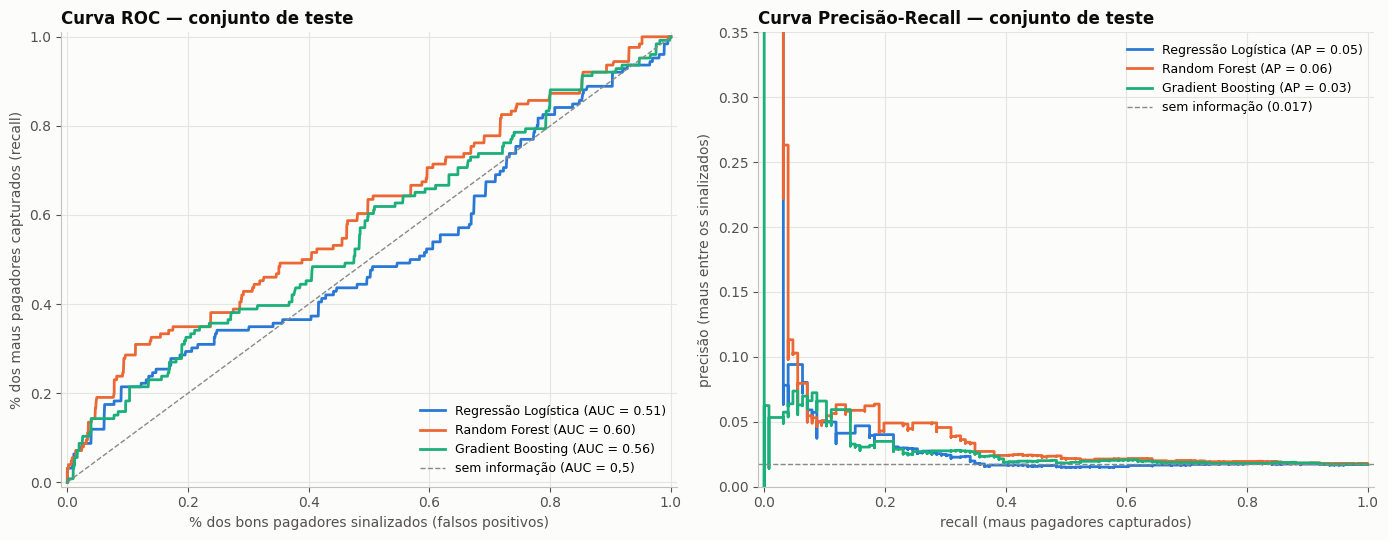

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for i, (nome, p) in enumerate(probas.items()):
    RocCurveDisplay.from_predictions(y_test, p, name=nomes[nome], ax=axes[0], color=CORES_MODELOS[i], linewidth=2)
    PrecisionRecallDisplay.from_predictions(y_test, p, name=nomes[nome], ax=axes[1], color=CORES_MODELOS[i], linewidth=2)
axes[0].plot([0, 1], [0, 1], color=COR_NEUTRA, linestyle="--", linewidth=1, label="sem informação (AUC = 0,5)")
axes[1].axhline(y_test.mean(), color=COR_NEUTRA, linestyle="--", linewidth=1, label=f"sem informação ({y_test.mean():.3f})")
axes[0].set_title("Curva ROC — conjunto de teste")
axes[1].set_title("Curva Precisão-Recall — conjunto de teste")
axes[1].set_ylim(0, 0.35)
axes[0].set_xlabel("% dos bons pagadores sinalizados (falsos positivos)")
axes[0].set_ylabel("% dos maus pagadores capturados (recall)")
axes[1].set_xlabel("recall (maus pagadores capturados)")
axes[1].set_ylabel("precisão (maus entre os sinalizados)")
for ax, loc in zip(axes, ["lower right", "upper right"]):
    ax.set_aspect("auto")
    ax.legend(loc=loc, fontsize=9)
fig.tight_layout()
salvar(fig, "04_curvas_roc_pr")
plt.show()

**Leitura:**

- **Curva ROC:** as três curvas sobem acima da diagonal no início. Os primeiros ~10% de pedidos
  sinalizados concentram mais maus pagadores que o acaso. Depois a Logística cruza a diagonal
  e anda abaixo dela na faixa intermediária. O Random Forest se mantém acima em quase todo o
  percurso.
- **Curva Precisão-Recall:** a precisão só se descola da linha de base (0,017) no recall baixo,
  até ~20–30%. Entre os pedidos de maior risco, de 5% a 10% são maus pagadores, de 3 a 6 vezes a
  média. Para recall acima de 40%, todos os modelos voltam ao nível do acaso.

**Conclusão:** o sinal está concentrado **no topo da lista de risco**. O modelo serve para
apontar uma **fatia pequena** de pedidos suspeitos, não para classificar toda a carteira.

## 4. Ponto de corte: quantos pedidos sinalizar?

O modelo não diz "aprova" ou "recusa". Ele dá uma **nota de risco**. A decisão de negócio é
**qual fatia dos pedidos de maior risco** vai para recusa ou análise manual.

O corte é escolhido **sem olhar o teste**. Geramos notas *out-of-fold* para o treino, ou seja,
cada cliente recebe a nota de um modelo que não o viu, com a mesma validação agrupada do
notebook 03. Depois medimos, no teste, o que aquela política teria entregado.

In [6]:
final = modelos[escolhido]
cv = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
nota_oof = cross_val_predict(final, treino[FEATURES], treino[TARGET], groups=treino[GROUP],
                             cv=cv, method="predict_proba")[:, 1]
nota_teste = probas[escolhido]

def politica(nota, y, corte):
    sinal = nota >= corte
    y = np.asarray(y)
    return {"% pedidos sinalizados": sinal.mean() * 100,
            "% dos maus barrados": y[sinal].sum() / y.sum() * 100,
            "bons sinalizados por mau barrado": (sinal & (y == 0)).sum() / max((sinal & (y == 1)).sum(), 1),
            "% de maus entre os aprovados": y[~sinal].mean() * 100}

fatias = [0.05, 0.10, 0.20, 0.30, 0.50]
linhas = []
for f in fatias:
    corte = np.quantile(nota_oof, 1 - f)
    for conjunto, nota, y in [("treino (out-of-fold)", nota_oof, treino[TARGET]), ("teste", nota_teste, y_test)]:
        linhas.append({"fatia alvo": f"{f:.0%}", "conjunto": conjunto, "corte": round(corte, 3), **politica(nota, y, corte)})
politicas = pd.DataFrame(linhas).set_index(["fatia alvo", "conjunto"]).round(2)
politicas

corte  % pedidos sinalizados  \
fatia alvo conjunto                                             
5%         treino (out-of-fold)   0.63                   5.02   
           teste                  0.63                   3.37   
10%        treino (out-of-fold)   0.59                  10.01   
           teste                  0.59                   8.04   
20%        treino (out-of-fold)   0.55                  20.00   
           teste                  0.55                  19.66   
30%        treino (out-of-fold)   0.52                  30.00   
           teste                  0.52                  30.05   
50%        treino (out-of-fold)   0.47                  50.01   
           teste                  0.47                  49.63   

                                 % dos maus barrados  \
fatia alvo conjunto                                    
5%         treino (out-of-fold)                11.84   
           teste                                8.73   
10%        treino (out-of-fold)                18.37   
           teste                               18.25   
20%        treino (out-of-fold)                29.80   
           teste                               28.57   
30%        treino (out-of-fold)                40.20   
           teste                               34.13   
50%        treino (out-of-fold)                58.57   
           teste                               46.03   

                                 bons sinalizados por mau barrado  \
fatia alvo conjunto                                                 
5%         treino (out-of-fold)                             24.21   
           teste                                            21.55   
10%        treino (out-of-fold)                             31.37   
           teste                                            24.70   
20%        treino (out-of-fold)                             38.87   
           teste                                            39.17   
30%        treino (out-of-fold)                             43.32   
           teste                                            50.40   
50%        treino (out-of-fold)                             49.71   
           teste                                            61.93   

                                 % de maus entre os aprovados  
fatia alvo conjunto                                            
5%         treino (out-of-fold)                          1.56  
           teste                                         1.62  
10%        treino (out-of-fold)                          1.53  
           teste                                         1.52  
20%        treino (out-of-fold)                          1.48  
           teste                                         1.52  
30%        treino (out-of-fold)                          1.44  
           teste                                         1.61  
50%        treino (out-of-fold)                          1.40  
           teste                                         1.84

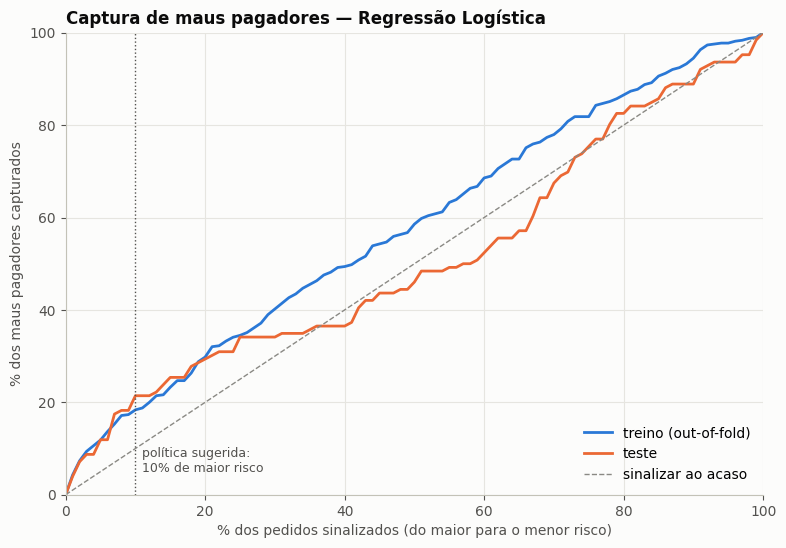

In [7]:
fracoes = np.linspace(0, 1, 101)
def curva_captura(nota, y):
    ordem = np.argsort(-nota)
    acumulado = np.cumsum(np.asarray(y)[ordem]) / np.sum(y)
    idx = np.clip((fracoes * len(nota)).astype(int) - 1, 0, len(nota) - 1)
    return np.where(fracoes == 0, 0, acumulado[idx]) * 100

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(fracoes * 100, curva_captura(nota_oof, treino[TARGET]), color=COR_BOM, linewidth=2, label="treino (out-of-fold)")
ax.plot(fracoes * 100, curva_captura(nota_teste, y_test), color=COR_MAU, linewidth=2, label="teste")
ax.plot([0, 100], [0, 100], color=COR_NEUTRA, linestyle="--", linewidth=1, label="sinalizar ao acaso")
ax.axvline(10, color="#52514e", linestyle=":", linewidth=1)
ax.text(11, 5, "política sugerida:\n10% de maior risco", fontsize=9, color="#52514e")
ax.set_xlabel("% dos pedidos sinalizados (do maior para o menor risco)")
ax.set_ylabel("% dos maus pagadores capturados")
ax.set_title(f"Captura de maus pagadores — {nomes[escolhido]}")
ax.legend(loc="lower right")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
salvar(fig, "04_curva_captura")
plt.show()

# Pontos da curva, usados no gráfico interativo da apresentação em HTML.
pd.DataFrame({"pct_sinalizados": fracoes * 100,
              "treino_oof": curva_captura(nota_oof, treino[TARGET]),
              "teste": curva_captura(nota_teste, y_test)}).round(2).to_csv(METRICS / "curva_captura.csv", index=False)

**Leitura e escolha da política:**

- No topo da lista, a política se reproduz quase perfeitamente do treino para o teste.
  Sinalizando os **10% de maior risco**, o modelo captura **18,4% dos maus pagadores** no treino
  (*out-of-fold*) e **18,3% no teste**: cerca de **2 vezes o que se pegaria sinalizando ao acaso**.
- Daí para baixo, as curvas se separam. No teste, a captura cola na diagonal entre 30% e 60%.
  Fatias maiores não acrescentam proteção real e só recusam mais bons clientes.
- **Custo da política dos 10%:** para cada mau pagador barrado, cerca de **25 bons pagadores** são
  sinalizados. Recusa automática só valeria a pena se um calote custasse mais que 25 vezes o
  lucro de um bom cliente. Em cartão de crédito, isso raramente acontece.

**Política sugerida:** enviar os **10% de pedidos com maior nota de risco para análise manual**,
com pedido de documentação extra ou limite inicial reduzido, **em vez de recusa automática**.
O corte (nota ≥ 0,593) foi fixado no treino.

## 5. Matriz de confusão (política dos 10%)

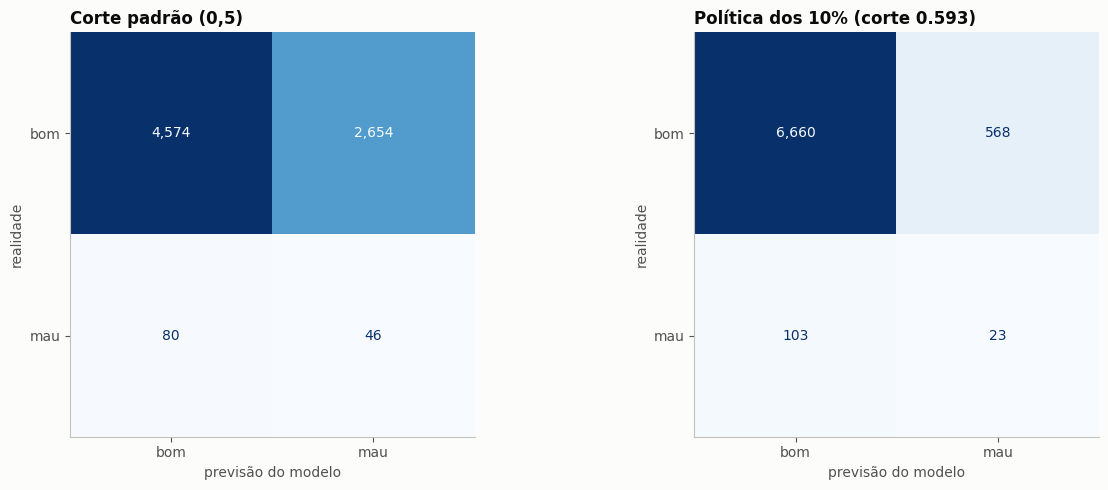

accuracy     0.909
precision    0.039
recall       0.183
f1           0.064
roc_auc      0.511
pr_auc       0.053
Name: política dos 10% — teste, dtype: float64

In [8]:
FATIA = 0.10
CORTE = float(np.quantile(nota_oof, 1 - FATIA))
pred_teste = (nota_teste >= CORTE).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (corte, titulo) in zip(axes, [(0.5, "Corte padrão (0,5)"), (CORTE, f"Política dos 10% (corte {CORTE:.3f})")]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, (nota_teste >= corte).astype(int), display_labels=["bom", "mau"],
        cmap="Blues", colorbar=False, ax=ax, values_format=",d")
    ax.set_xlabel("previsão do modelo")
    ax.set_ylabel("realidade")
    ax.set_title(titulo)
    ax.grid(False)
fig.tight_layout()
salvar(fig, "04_matriz_confusao")
plt.show()

pd.Series(score(y_test, pred_teste, nota_teste)).round(3).rename("política dos 10% — teste")

**Leitura** (teste, 7.354 clientes, 126 maus pagadores):

- **Corte padrão (0,5):** sinaliza 37% de todos os pedidos para capturar 46 maus pagadores. É
  inviável operacionalmente.
- **Política dos 10%:** na prática sinaliza 591 pedidos (8%). Captura **23 dos 126 maus
  pagadores** (recall de 18%). **Os 3 cadastros inconsistentes do teste estão entre os 23.** Entre
  os sinalizados, 3,9% são maus pagadores (precisão), **2,3 vezes a taxa média** de 1,7%.
- Os 103 maus pagadores que passam têm perfil cadastral indistinguível do de um bom pagador.
  Nenhum corte os separa sem recusar a maior parte da carteira. Esse é o limite dos dados
  disponíveis, não do modelo.

## 6. Importância das variáveis

Duas leituras complementares:

1. **Coeficientes da Regressão Logística:** o que o modelo aprendeu. Com atributos padronizados,
   o coeficiente indica quanto o risco sobe ou desce para cada desvio-padrão a mais (numéricas)
   ou para quem pertence à categoria (categóricas). Exibimos a **razão de chances**:
   `exp(coeficiente)`. Um valor de 1,10 significa 10% a mais de chance de ser mau pagador.
2. **Importância por permutação no teste:** quanto a AUC-ROC cai quando embaralhamos uma variável.
   Mede o que de fato **ajuda a prever clientes novos**. Repetimos 30 vezes para estimar a
   incerteza.

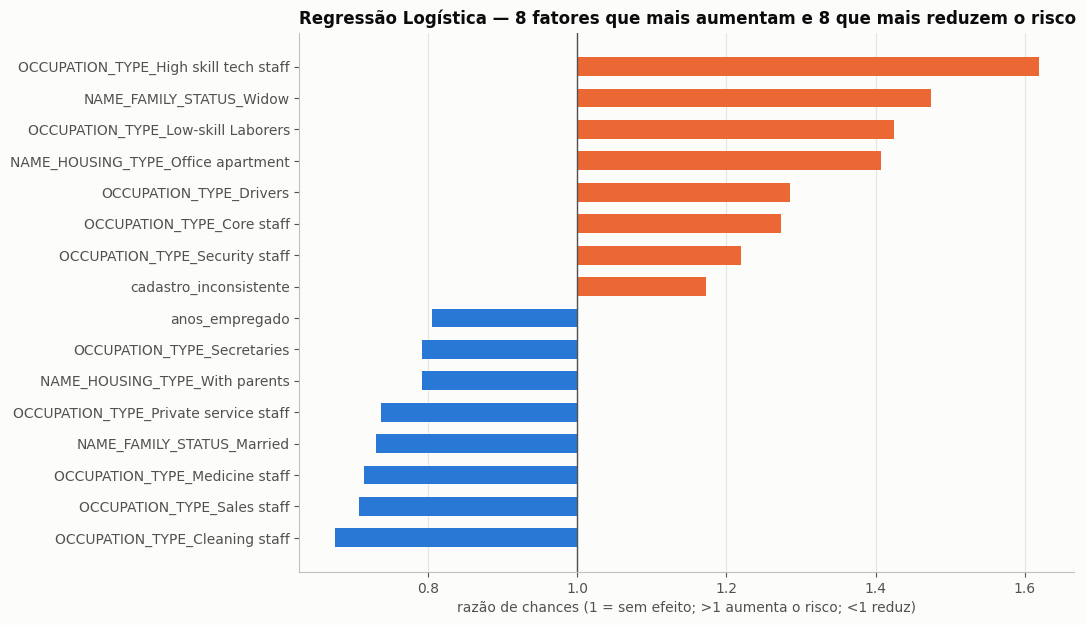

In [9]:
lr = modelos["regressao_logistica"]
nomes_saida = lr.named_steps["prep"].get_feature_names_out()
coef = pd.Series(lr.named_steps["clf"].coef_[0], index=nomes_saida)
coef.index = coef.index.str.replace("num__", "").str.replace("cat__", "")
razao = np.exp(coef).sort_values()
principais = pd.concat([razao.head(8), razao.tail(8)])

fig, ax = plt.subplots(figsize=(10, 7))
cores = [COR_MAU if v > 1 else COR_BOM for v in principais]
ax.barh(principais.index, principais.values - 1, left=1, color=cores, height=0.6)
ax.axvline(1, color="#52514e", linewidth=1)
ax.set_xlabel("razão de chances (1 = sem efeito; >1 aumenta o risco; <1 reduz)")
ax.set_title("Regressão Logística — 8 fatores que mais aumentam e 8 que mais reduzem o risco")
ax.grid(axis="y", visible=False)
salvar(fig, "04_coeficientes")
plt.show()

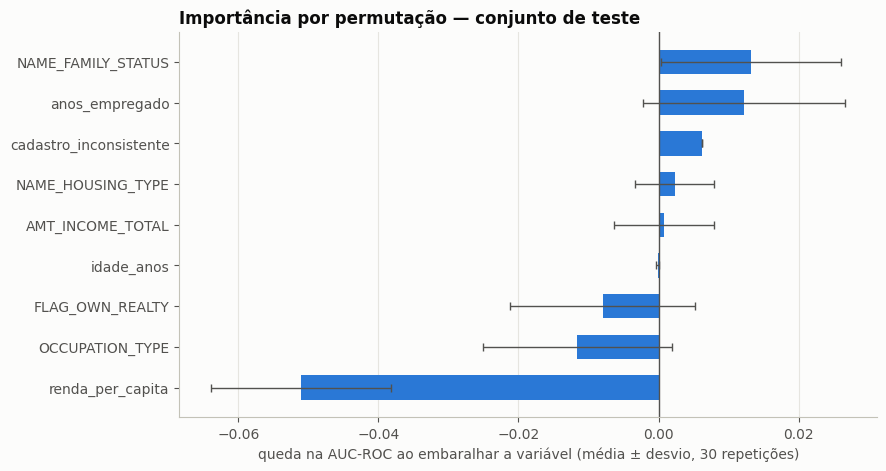

,queda_media_auc,desvio
renda_per_capita,-0.0510,0.0128
OCCUPATION_TYPE,-0.0116,0.0135
FLAG_OWN_REALTY,-0.0080,0.0132
idade_anos,-0.0001,0.0002
AMT_INCOME_TOTAL,0.0008,0.0072
NAME_HOUSING_TYPE,0.0023,0.0056
cadastro_inconsistente,0.0062,0.0001
anos_empregado,0.0122,0.0144
NAME_FAMILY_STATUS,0.0132,0.0128


In [10]:
perm = permutation_importance(final, X_test, y_test, scoring="roc_auc", n_repeats=30,
                              random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.DataFrame({"queda_media_auc": perm.importances_mean, "desvio": perm.importances_std},
                   index=FEATURES).sort_values("queda_media_auc")
imp.to_csv(METRICS / "importancia_permutacao.csv")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp.index, imp["queda_media_auc"], xerr=imp["desvio"], color=COR_BOM, height=0.6,
        error_kw={"ecolor": "#52514e", "elinewidth": 1, "capsize": 3})
ax.axvline(0, color="#52514e", linewidth=1)
ax.set_xlabel("queda na AUC-ROC ao embaralhar a variável (média ± desvio, 30 repetições)")
ax.set_title("Importância por permutação — conjunto de teste")
ax.grid(axis="y", visible=False)
salvar(fig, "04_importancia_permutacao")
plt.show()
imp.round(4)

**Leitura:**

**O que o modelo aprendeu** (razões de chance da Regressão Logística):

- **Aumentam o risco:** ocupações como técnicos especializados (*High skill tech staff*, 1,62),
  trabalhadores de baixa qualificação (1,42), motoristas, segurança e *core staff*. Também ser
  viúvo (1,48), morar em apartamento funcional (1,41) e ter cadastro inconsistente (1,17).
  Na escala do modelo, o efeito da última variável parece pequeno porque ela atinge só 17
  pessoas. Na prática, os 3 casos do teste foram todos sinalizados.
- **Reduzem o risco:** **tempo no emprego atual** (0,81 por desvio-padrão, cerca de 6 anos a mais),
  **ter imóvel próprio** (0,83), ser casado (0,73), morar com os pais (0,79) e ocupações como
  limpeza, vendas, área médica e serviços privados (0,67–0,74).
- **Renda:** o modelo combina renda total (1,10) e renda per capita (0,82) com sinais opostos, um
  contraste do tipo "renda alta, mas dividida por uma família grande".
- **Idade:** efeito praticamente nulo (0,997) depois de considerar as outras variáveis.

**O que funciona em clientes novos** (permutação no teste):

- Ajudam a prever: **estado civil** (+0,013 de AUC), **tempo de emprego** (+0,012) e
  **cadastro inconsistente** (+0,006, o efeito mais estável, com desvio de 0,0001).
- **Renda per capita prejudica:** embaralhá-la *melhora* a AUC em 0,05. O contraste entre as rendas
  aprendido no treino não se repete no teste. Esse é o principal motivo de a Logística ter ido mal
  na ordenação completa: renda declarada é ruído, como a EDA já sugeria (seção 3.2 do 01).
- Ocupação e imóvel próprio têm efeito dentro do ruído (desvio maior que a média).

**Faz sentido no domínio?** Em grande parte, sim. **Estabilidade** (tempo de emprego, imóvel
próprio, casamento) reduz o risco, e **sinais de fragilidade ou inconsistência** o aumentam. A
exceção é a renda declarada, que não tem relação confiável com o pagamento nesta base.
Provavelmente ela não é comprovada.

In [11]:
# Números-chave da política, usados na apresentação executiva (src/apresentacao.py).
pol_teste = politica(nota_teste, y_test, CORTE)
resumo = {
    "modelo": nomes[escolhido],
    "clientes_base": int(len(df)),
    "taxa_maus_pct": round(df[TARGET].mean() * 100, 2),
    "teste_clientes": int(len(teste)),
    "teste_maus": int(y_test.sum()),
    "auc_teste": round(roc_auc_score(y_test, nota_teste), 3),
    "pr_auc_teste": round(average_precision_score(y_test, nota_teste), 3),
    "auc_cv": round(pd.read_csv(METRICS / "validacao_cruzada.csv", index_col=0).loc[escolhido, "roc_auc_mean"], 3),
    "politica_fatia_pct": round(pol_teste["% pedidos sinalizados"], 1),
    "politica_maus_barrados_pct": round(pol_teste["% dos maus barrados"], 1),
    "politica_bons_por_mau": round(pol_teste["bons sinalizados por mau barrado"], 1),
    "politica_maus_barrados_pct_oof": round(politicas.loc[("10%", "treino (out-of-fold)"), "% dos maus barrados"], 1),
    "inconsistentes_teste": int(teste["cadastro_inconsistente"].sum()),
    "inconsistentes_sinalizados": int(pred_teste[teste["cadastro_inconsistente"].values == 1].sum()),
}
with open(METRICS / "resumo_negocio.json", "w", encoding="utf-8") as f:
    json.dump(resumo, f, ensure_ascii=False, indent=2)
resumo

{'modelo': 'Regressão Logística',
 'clientes_base': 36457,
 'taxa_maus_pct': np.float64(1.69),
 'teste_clientes': 7354,
 'teste_maus': 126,
 'auc_teste': np.float64(0.511),
 'pr_auc_teste': np.float64(0.053),
 'auc_cv': np.float64(0.578),
 'politica_fatia_pct': np.float64(8.0),
 'politica_maus_barrados_pct': np.float64(18.3),
 'politica_bons_por_mau': np.float64(24.7),
 'politica_maus_barrados_pct_oof': np.float64(18.4),
 'inconsistentes_teste': 3,
 'inconsistentes_sinalizados': 3}

## 7. Implicações práticas

**O que a área de crédito faria de diferente a partir destes resultados:**

1. **Não automatizar a recusa com base só no cadastro.** Com o que o cliente informa no pedido, o
   melhor modelo identifica cerca de 1 em cada 5 maus pagadores. Para isso, sinaliza 25 bons
   clientes para cada mau. Recusar todos esses pedidos custaria mais receita do que evitaria
   perdas.
2. **Usar o modelo como triagem.** Os 10% de pedidos com maior nota vão para análise manual, com
   documentação extra ou limite inicial menor. Nessa fatia a concentração de maus pagadores é
   2 vezes maior que na média, e o resultado se repetiu em clientes que o modelo nunca viu.
3. **Criar uma regra de alerta para cadastros contraditórios.** Os 17 clientes declarados
   pensionistas e com emprego ativo foram **todos** maus pagadores. Inconsistências cadastrais
   devem disparar verificação. Essa regra é simples, barata e independe do modelo.
4. **Valorizar sinais de estabilidade na análise:** tempo no emprego atual, imóvel próprio e
   situação familiar. A renda declarada não deve pesar sozinha na decisão.
5. **O ganho real virá de dados melhores.** O cadastro explica pouco do comportamento de
   pagamento. Consulta a bureau de crédito (score, restrições, endividamento), comprovação de
   renda e histórico de relacionamento com o banco são os dados que tipicamente levam modelos de
   crédito a outro patamar.

## 8. Limitações e próximos passos

**Onde o modelo falha:**

- **Poder de previsão baixo e instável.** AUC de 0,51 a 0,60 no teste, conforme o modelo, com
  intervalos que se sobrepõem. A Logística escolhida não superou o acaso na ordenação completa.
  Só o topo da lista de risco é confiável.
- **Poucos maus pagadores:** 616 na base e 126 no teste. Qualquer métrica varia vários pontos
  com a mudança de poucos casos.
- **Cadastro inconsistente:** a regra se apoia em só 17 casos e pode ser uma peculiaridade de como
  o dataset foi montado. Precisa ser validada com dados novos antes de virar política.
- **Sem data do pedido:** não sabemos quando cada cadastro foi feito em relação ao histórico. Uma
  validação temporal (treinar no passado, testar no futuro) seria mais realista.
- **Viés de seleção:** só há rótulo para quem **foi aprovado** e virou cliente. O modelo nunca viu
  pedidos recusados, que são justamente os mais arriscados.
- **Renda declarada** parece não comprovada (valores redondos) e prejudicou a previsão.

**Com mais tempo ou mais dados:**

- incorporar dados de bureau de crédito e comprovação de renda;
- testar **retirar as variáveis de renda** do modelo (a permutação sugere ganho), com nova validação
  cruzada, sem usar o teste;
- calibrar as probabilidades e definir o corte a partir do custo real de calote e de cliente perdido;
- avaliar equidade entre grupos (sexo, idade) antes de qualquer uso em produção;
- monitorar o modelo em produção e retreiná-lo quando o perfil dos solicitantes mudar.